# Exploratory Data Analysis (EDA)

**Bluestock Fintech — Mutual Fund Analytics Capstone**

Date: June 2026

In [1]:
"""
Bluestock Fintech — Mutual Fund Analytics Capstone
D3: Exploratory Data Analysis (EDA) — 15+ Publication-Quality Charts

Reads raw CSV data, performs inline cleaning, and generates 15 charts
saved to charts/ directory. Prints 10 key EDA findings at the end.
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # disabled for notebook
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ──────────────────────────────────────────────
# Paths
# ──────────────────────────────────────────────
from pathlib import Path
BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW = BASE / 'data' / 'raw'
PROCESSED = BASE / 'data' / 'processed'
CHARTS = BASE / 'charts'
DB = BASE / 'data' / 'db' / 'bluestock_mf.db'
CHARTS.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────
# Style & Palette
# ──────────────────────────────────────────────
plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5",
]
sns.set_palette(PALETTE)

TITLE_KW = dict(fontsize=14, fontweight="bold", pad=12)
DPI = 150


print('Code cell 1 executed successfully.')


Code cell 1 executed successfully.


In [2]:
def load_data():
    """Load all raw CSVs with minimal inline cleaning."""
    data = {}
    data["fund_master"]   = pd.read_csv(RAW / "01_fund_master.csv")
    data["nav_history"]   = pd.read_csv(RAW / "02_nav_history.csv", parse_dates=["date"])
    data["aum"]           = pd.read_csv(RAW / "03_aum_by_fund_house.csv", parse_dates=["date"])
    data["sip"]           = pd.read_csv(RAW / "04_monthly_sip_inflows.csv")
    data["sip"]["month"]  = pd.to_datetime(data["sip"]["month"])
    data["cat_inflows"]   = pd.read_csv(RAW / "05_category_inflows.csv")
    data["cat_inflows"]["month"] = pd.to_datetime(data["cat_inflows"]["month"])
    data["folio"]         = pd.read_csv(RAW / "06_industry_folio_count.csv")
    data["folio"]["month"] = pd.to_datetime(data["folio"]["month"])
    data["performance"]   = pd.read_csv(RAW / "07_scheme_performance.csv")
    data["transactions"]  = pd.read_csv(RAW / "08_investor_transactions.csv", parse_dates=["transaction_date"])
    data["holdings"]      = pd.read_csv(RAW / "09_portfolio_holdings.csv")
    data["benchmark"]     = pd.read_csv(RAW / "10_benchmark_indices.csv", parse_dates=["date"])
    return data


# ──────────────────────────────────────────────
# Chart 1: NAV Trend Lines
# ──────────────────────────────────────────────

print('Function load_data defined successfully.')


Function load_data defined successfully.


In [3]:
def chart_nav_trend(data):
    """Daily NAV for top 10 schemes (2022–2026) with legend."""
    nav = data["nav_history"]
    fm  = data["fund_master"]
    perf = data["performance"]

    top10_codes = perf.nlargest(10, "aum_crore")["amfi_code"].values
    nav_top = nav[nav["amfi_code"].isin(top10_codes)].copy()

    name_map = fm.set_index("amfi_code")["scheme_name"].to_dict()
    # Shorten names for legend
    def shorten(name):
        return name.replace(" - Regular Plan - Growth", "").replace(" - Direct Plan - Growth", " (D)")[:40]

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, code in enumerate(top10_codes):
        sub = nav_top[nav_top["amfi_code"] == code].sort_values("date")
        label = shorten(name_map.get(code, str(code)))
        ax.plot(sub["date"], sub["nav"], label=label, linewidth=1.2, color=PALETTE[i % len(PALETTE)])
    ax.set_title("NAV Trend Lines — Top 10 Schemes (2022-2026)", **TITLE_KW)
    ax.set_xlabel("Date")
    ax.set_ylabel("NAV (₹)")
    ax.legend(fontsize=7, loc="upper left", ncol=2, framealpha=0.9)
    plt.tight_layout()
    fig.savefig(CHARTS / "nav_trend_lines.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  1/15: NAV Trend Lines saved to charts/nav_trend_lines.png")


# ──────────────────────────────────────────────
# Chart 2: AUM Growth by Fund House
# ──────────────────────────────────────────────

print('Function chart_nav_trend defined successfully.')


Function chart_nav_trend defined successfully.


In [4]:
def chart_aum_growth(data):
    """Grouped bar chart — quarterly AUM for top 10 AMCs."""
    aum = data["aum"].copy()
    aum["quarter"] = aum["date"].dt.to_period("Q").astype(str)

    top10 = aum.groupby("fund_house")["aum_crore"].max().nlargest(10).index
    aum_top = aum[aum["fund_house"].isin(top10)]

    pivot = aum_top.pivot_table(index="fund_house", columns="quarter", values="aum_crore", aggfunc="mean")
    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(14, 7))
    pivot.plot(kind="bar", ax=ax, width=0.8, colormap="tab10")
    ax.set_title("AUM Growth by Fund House — Quarterly (Top 10 AMCs)", **TITLE_KW)
    ax.set_ylabel("AUM (₹ Crore)")
    ax.set_xlabel("")
    ax.legend(title="Quarter", fontsize=7, ncol=3, framealpha=0.9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}L Cr"))
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fig.savefig(CHARTS / "aum_growth_fund_house.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  2/15: AUM Growth by Fund House saved to charts/aum_growth_fund_house.png")


# ──────────────────────────────────────────────
# Chart 3: SIP Inflow Trend
# ──────────────────────────────────────────────

print('Function chart_aum_growth defined successfully.')


Function chart_aum_growth defined successfully.


In [5]:
def chart_sip_inflow(data):
    """Monthly line chart Jan 2022 – Dec 2025, annotate Dec 2025 peak ₹31,002 Cr."""
    sip = data["sip"].sort_values("month")

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(sip["month"], sip["sip_inflow_crore"], color=PALETTE[0], linewidth=2, marker="o", markersize=3)
    ax.fill_between(sip["month"], sip["sip_inflow_crore"], alpha=0.15, color=PALETTE[0])

    # Annotate Dec 2025 peak
    peak = sip[sip["sip_inflow_crore"] == sip["sip_inflow_crore"].max()].iloc[0]
    ax.annotate(
        f"Peak: ₹{peak['sip_inflow_crore']:,.0f} Cr",
        xy=(peak["month"], peak["sip_inflow_crore"]),
        xytext=(peak["month"] - pd.Timedelta(days=180), peak["sip_inflow_crore"] + 2000),
        fontsize=10, fontweight="bold", color=PALETTE[3],
        arrowprops=dict(arrowstyle="->", color=PALETTE[3], lw=1.5),
    )
    ax.set_title("SIP Inflow Trend — Jan 2022 to Dec 2025", **TITLE_KW)
    ax.set_xlabel("Month")
    ax.set_ylabel("SIP Inflow (₹ Crore)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e3:.0f}K Cr"))
    plt.tight_layout()
    fig.savefig(CHARTS / "sip_inflow_trend.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  3/15: SIP Inflow Trend saved to charts/sip_inflow_trend.png")


# ──────────────────────────────────────────────
# Chart 4: Category-wise Inflow Heatmap
# ──────────────────────────────────────────────

print('Function chart_sip_inflow defined successfully.')


Function chart_sip_inflow defined successfully.


In [6]:
def chart_category_heatmap(data):
    """Months on X, categories on Y, net inflow as color."""
    ci = data["cat_inflows"].copy()
    ci["month_str"] = ci["month"].dt.strftime("%Y-%m")
    pivot = ci.pivot_table(index="category", columns="month_str", values="net_inflow_crore", aggfunc="sum")
    pivot = pivot.fillna(0)

    fig, ax = plt.subplots(figsize=(16, 7))
    sns.heatmap(pivot, cmap="RdYlGn", center=0, linewidths=0.5, fmt=".0f",
                annot=True, annot_kws={"fontsize": 7}, ax=ax, cbar_kws={"label": "Net Inflow (₹ Cr)"})
    ax.set_title("Category-wise Net Inflow Heatmap", **TITLE_KW)
    ax.set_xlabel("Month")
    ax.set_ylabel("")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    fig.savefig(CHARTS / "category_inflow_heatmap.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  4/15: Category-wise Inflow Heatmap saved to charts/category_inflow_heatmap.png")


# ──────────────────────────────────────────────
# Chart 5: Investor Age Distribution (Pie)
# ──────────────────────────────────────────────

print('Function chart_category_heatmap defined successfully.')


Function chart_category_heatmap defined successfully.


In [7]:
def chart_age_distribution(data):
    """Pie chart of age groups."""
    txn = data["transactions"]
    age_counts = txn["age_group"].value_counts()
    order = ["18-25", "26-35", "36-45", "46-55", "56+"]
    age_counts = age_counts.reindex([a for a in order if a in age_counts.index])

    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        age_counts, labels=age_counts.index, autopct="%1.1f%%",
        colors=PALETTE[:len(age_counts)], startangle=140,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
        textprops={"fontsize": 11},
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight("bold")
    ax.set_title("Investor Age Distribution", **TITLE_KW)
    plt.tight_layout()
    fig.savefig(CHARTS / "investor_age_distribution.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  5/15: Investor Age Distribution saved to charts/investor_age_distribution.png")


# ──────────────────────────────────────────────
# Chart 6: SIP Amount by Age Group (Box plot)
# ──────────────────────────────────────────────

print('Function chart_age_distribution defined successfully.')


Function chart_age_distribution defined successfully.


In [8]:
def chart_sip_amount_by_age(data):
    """Box plot of SIP amounts by age group."""
    txn = data["transactions"]
    sip_txn = txn[txn["transaction_type"] == "SIP"].copy()
    order = ["18-25", "26-35", "36-45", "46-55", "56+"]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", order=order,
                palette=PALETTE[:5], ax=ax, showfliers=False)
    ax.set_title("SIP Amount Distribution by Age Group", **TITLE_KW)
    ax.set_xlabel("Age Group")
    ax.set_ylabel("SIP Amount (₹)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
    plt.tight_layout()
    fig.savefig(CHARTS / "sip_amount_by_age.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  6/15: SIP Amount by Age Group saved to charts/sip_amount_by_age.png")


# ──────────────────────────────────────────────
# Chart 7: Geographic Distribution (Top 15 states)
# ──────────────────────────────────────────────

print('Function chart_sip_amount_by_age defined successfully.')


Function chart_sip_amount_by_age defined successfully.


In [9]:
def chart_geographic_distribution(data):
    """Horizontal bar chart of transaction amount by state (top 15)."""
    txn = data["transactions"]
    state_amt = txn.groupby("state")["amount_inr"].sum().nlargest(15).sort_values()

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(state_amt.index, state_amt.values, color=PALETTE[:15])
    ax.set_title("Geographic Distribution — Transaction Amount by State (Top 15)", **TITLE_KW)
    ax.set_xlabel("Total Transaction Amount (₹)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e7:.1f} Cr"))
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.01, bar.get_y() + bar.get_height()/2, f"₹{w/1e7:.1f} Cr",
                va="center", fontsize=8)
    plt.tight_layout()
    fig.savefig(CHARTS / "geographic_distribution.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  7/15: Geographic Distribution saved to charts/geographic_distribution.png")


# ──────────────────────────────────────────────
# Chart 8: T30 vs B30 City Tier Distribution
# ──────────────────────────────────────────────

print('Function chart_geographic_distribution defined successfully.')


Function chart_geographic_distribution defined successfully.


In [10]:
def chart_t30_b30(data):
    """Pie chart of city tier distribution."""
    txn = data["transactions"]
    tier_counts = txn["city_tier"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 8))
    colors_tier = [PALETTE[0], PALETTE[1]]
    explode = (0.03, 0.03)
    wedges, texts, autotexts = ax.pie(
        tier_counts, labels=tier_counts.index, autopct="%1.1f%%",
        colors=colors_tier, startangle=90, explode=explode,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops={"fontsize": 12},
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight("bold")
    ax.set_title("T30 vs B30 — City Tier Distribution", **TITLE_KW)
    plt.tight_layout()
    fig.savefig(CHARTS / "t30_vs_b30.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  8/15: T30 vs B30 Distribution saved to charts/t30_vs_b30.png")


# ──────────────────────────────────────────────
# Chart 9: Folio Count Growth
# ──────────────────────────────────────────────

print('Function chart_t30_b30 defined successfully.')


Function chart_t30_b30 defined successfully.


In [11]:
def chart_folio_growth(data):
    """Line chart showing total folio growth."""
    folio = data["folio"].sort_values("month")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(folio["month"], folio["total_folios_crore"], color=PALETTE[0],
            linewidth=2.5, marker="o", markersize=5, label="Total Folios")
    ax.plot(folio["month"], folio["equity_folios_crore"], color=PALETTE[1],
            linewidth=1.5, marker="s", markersize=4, label="Equity Folios")
    ax.plot(folio["month"], folio["debt_folios_crore"], color=PALETTE[2],
            linewidth=1.5, marker="^", markersize=4, label="Debt Folios")
    ax.fill_between(folio["month"], folio["total_folios_crore"], alpha=0.1, color=PALETTE[0])

    ax.set_title("Folio Count Growth — Industry Level", **TITLE_KW)
    ax.set_xlabel("Month")
    ax.set_ylabel("Folios (Crore)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    fig.savefig(CHARTS / "folio_count_growth.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart  9/15: Folio Count Growth saved to charts/folio_count_growth.png")


# ──────────────────────────────────────────────
# Chart 10: NAV Return Correlation Matrix
# ──────────────────────────────────────────────

print('Function chart_folio_growth defined successfully.')


Function chart_folio_growth defined successfully.


In [12]:
def chart_nav_correlation(data):
    """Heatmap for 10 selected funds' daily returns."""
    nav = data["nav_history"]
    fm  = data["fund_master"]
    perf = data["performance"]

    top10_codes = perf.nlargest(10, "aum_crore")["amfi_code"].values
    name_map = fm.set_index("amfi_code")["scheme_name"].to_dict()

    pivot = nav[nav["amfi_code"].isin(top10_codes)].pivot_table(
        index="date", columns="amfi_code", values="nav"
    )
    returns = pivot.pct_change().dropna()
    corr = returns.corr()

    short_names = [name_map.get(c, str(c)).replace(" - Regular Plan - Growth", "").replace(" - Direct Plan - Growth", " (D)")[:25]
                   for c in corr.columns]
    corr.columns = short_names
    corr.index = short_names

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1,
                annot_kws={"fontsize": 8})
    ax.set_title("NAV Return Correlation Matrix — Top 10 Funds", **TITLE_KW)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    fig.savefig(CHARTS / "nav_return_correlation.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart 10/15: NAV Return Correlation Matrix saved to charts/nav_return_correlation.png")


# ──────────────────────────────────────────────
# Chart 11: Sector Allocation Donut
# ──────────────────────────────────────────────

print('Function chart_nav_correlation defined successfully.')


Function chart_nav_correlation defined successfully.


In [13]:
def chart_sector_donut(data):
    """Sector weights from portfolio holdings (aggregate across funds)."""
    hold = data["holdings"]
    sector_wt = hold.groupby("sector")["weight_pct"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 9))
    colors = PALETTE[:len(sector_wt)]
    wedges, texts, autotexts = ax.pie(
        sector_wt, labels=sector_wt.index, autopct="%1.1f%%",
        colors=colors, startangle=90, pctdistance=0.8,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.5),
        textprops={"fontsize": 9},
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight("bold")
    ax.set_title("Sector Allocation — Average Weight Across Funds", **TITLE_KW)
    plt.tight_layout()
    fig.savefig(CHARTS / "sector_allocation_donut.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart 11/15: Sector Allocation Donut saved to charts/sector_allocation_donut.png")


# ──────────────────────────────────────────────
# Chart 12: Transaction Type Split (Donut)
# ──────────────────────────────────────────────

print('Function chart_sector_donut defined successfully.')


Function chart_sector_donut defined successfully.


In [14]:
def chart_transaction_type(data):
    """Donut chart (SIP vs Lumpsum vs Redemption)."""
    txn = data["transactions"]
    type_counts = txn["transaction_type"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 8))
    colors_txn = [PALETTE[0], PALETTE[1], PALETTE[3]]
    wedges, texts, autotexts = ax.pie(
        type_counts, labels=type_counts.index, autopct="%1.1f%%",
        colors=colors_txn, startangle=90,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
        textprops={"fontsize": 12},
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
    centre_circle = plt.Circle((0, 0), 0.35, fc="white")
    ax.add_patch(centre_circle)
    ax.text(0, 0, f"Total\n{len(txn):,}", ha="center", va="center", fontsize=13, fontweight="bold")
    ax.set_title("Transaction Type Split", **TITLE_KW)
    plt.tight_layout()
    fig.savefig(CHARTS / "transaction_type_split.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart 12/15: Transaction Type Split saved to charts/transaction_type_split.png")


# ──────────────────────────────────────────────
# Chart 13: Fund Category Distribution
# ──────────────────────────────────────────────

print('Function chart_transaction_type defined successfully.')


Function chart_transaction_type defined successfully.


In [15]:
def chart_fund_category(data):
    """Bar chart of number of funds per sub-category."""
    fm = data["fund_master"]
    cat_counts = fm["sub_category"].value_counts().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(cat_counts.index, cat_counts.values, color=PALETTE[:len(cat_counts)])
    ax.set_title("Fund Sub-Category Distribution — Number of Schemes", **TITLE_KW)
    ax.set_xlabel("Number of Schemes")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.2, bar.get_y() + bar.get_height()/2, str(int(w)), va="center", fontsize=10)
    plt.tight_layout()
    fig.savefig(CHARTS / "fund_category_distribution.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart 13/15: Fund Category Distribution saved to charts/fund_category_distribution.png")


# ──────────────────────────────────────────────
# Chart 14: Monthly Transaction Volume
# ──────────────────────────────────────────────

print('Function chart_fund_category defined successfully.')


Function chart_fund_category defined successfully.


In [16]:
def chart_monthly_volume(data):
    """Line chart of transaction count per month."""
    txn = data["transactions"].copy()
    txn["month"] = txn["transaction_date"].dt.to_period("M").dt.to_timestamp()
    monthly = txn.groupby("month").size().reset_index(name="count")

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(monthly["month"], monthly["count"], color=PALETTE[4], linewidth=2, marker="o", markersize=4)
    ax.fill_between(monthly["month"], monthly["count"], alpha=0.15, color=PALETTE[4])
    ax.set_title("Monthly Transaction Volume", **TITLE_KW)
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of Transactions")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    fig.savefig(CHARTS / "monthly_transaction_volume.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart 14/15: Monthly Transaction Volume saved to charts/monthly_transaction_volume.png")


# ──────────────────────────────────────────────
# Chart 15: Top 10 Holdings
# ──────────────────────────────────────────────

print('Function chart_monthly_volume defined successfully.')


Function chart_monthly_volume defined successfully.


In [17]:
def chart_top_holdings(data):
    """Horizontal bar chart of top stocks by average weight."""
    hold = data["holdings"]
    top_stocks = hold.groupby("stock_name")["weight_pct"].mean().nlargest(10).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_stocks.index, top_stocks.values, color=PALETTE[:10])
    ax.set_title("Top 10 Holdings — Average Portfolio Weight Across Funds", **TITLE_KW)
    ax.set_xlabel("Average Weight (%)")
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.1, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va="center", fontsize=9)
    plt.tight_layout()
    fig.savefig(CHARTS / "top_10_holdings.png", dpi=DPI)
    plt.show()
    plt.close(fig)
    print("Chart 15/15: Top 10 Holdings saved to charts/top_10_holdings.png")


# ──────────────────────────────────────────────
# Key EDA Findings
# ──────────────────────────────────────────────

print('Function chart_top_holdings defined successfully.')


Function chart_top_holdings defined successfully.


  BLUESTOCK MF CAPSTONE — EDA ANALYSIS
  Generating 15 charts...



Loaded 10 datasets.


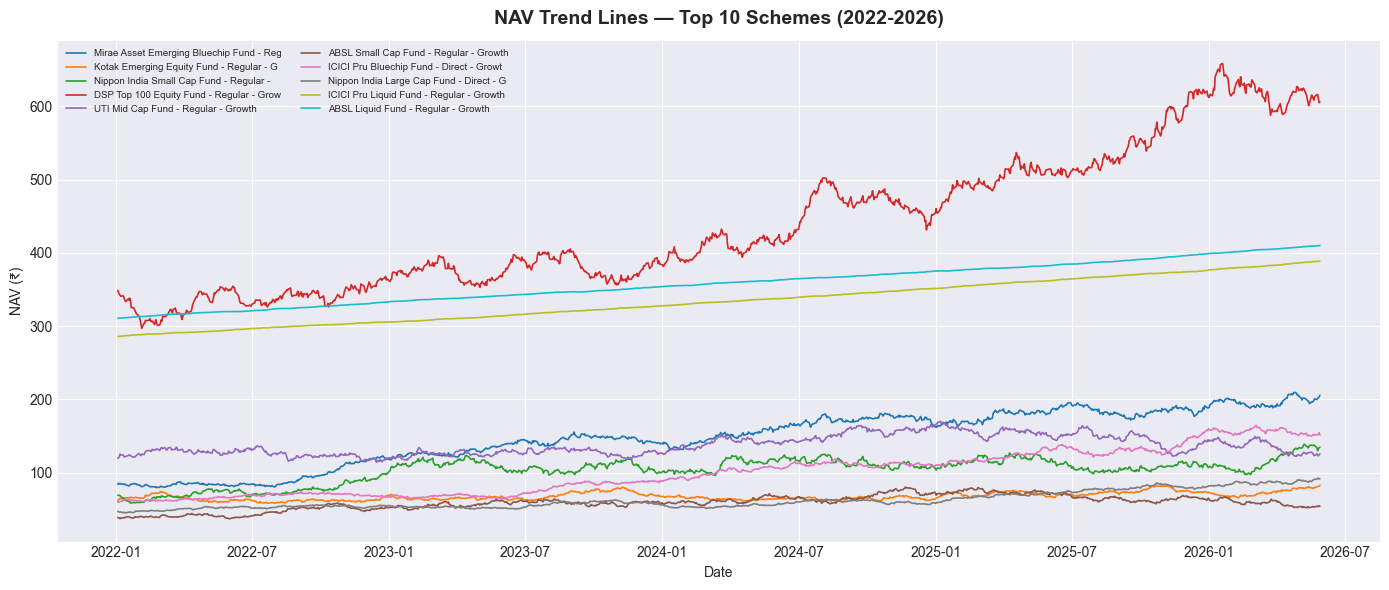

Chart  1/15: NAV Trend Lines saved to charts/nav_trend_lines.png


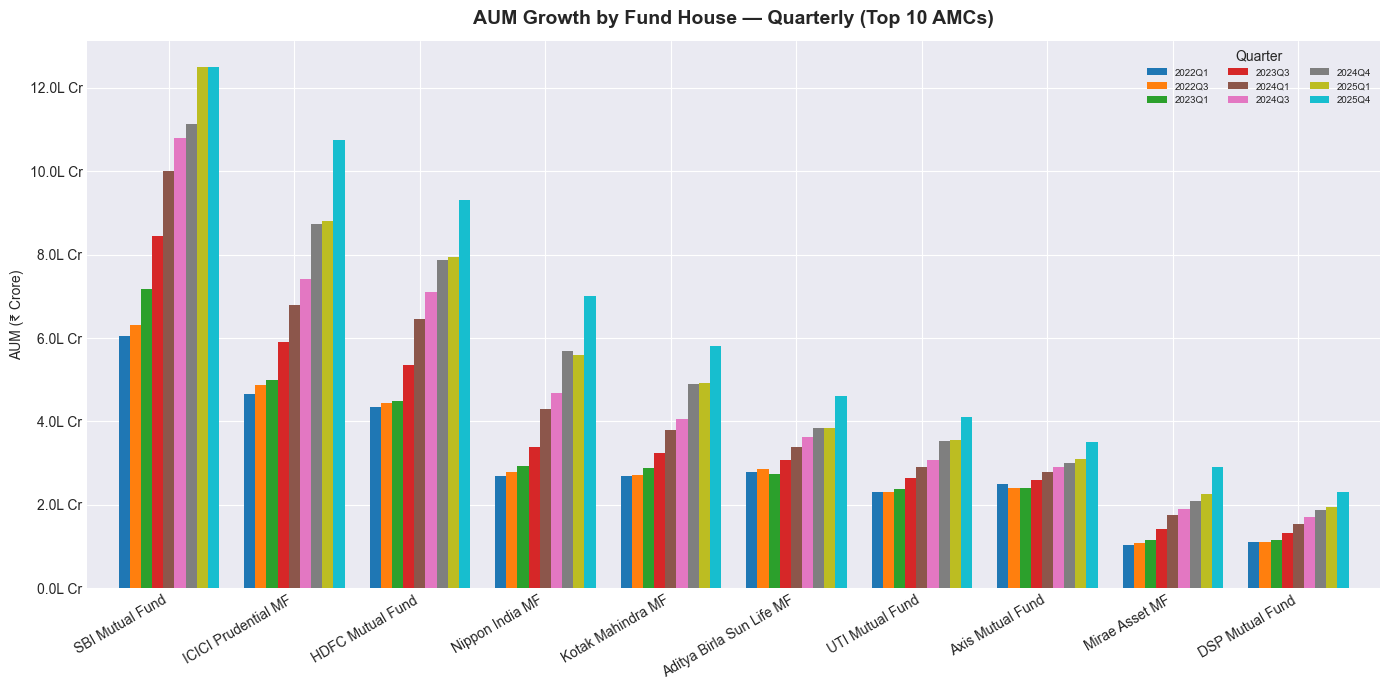

Chart  2/15: AUM Growth by Fund House saved to charts/aum_growth_fund_house.png


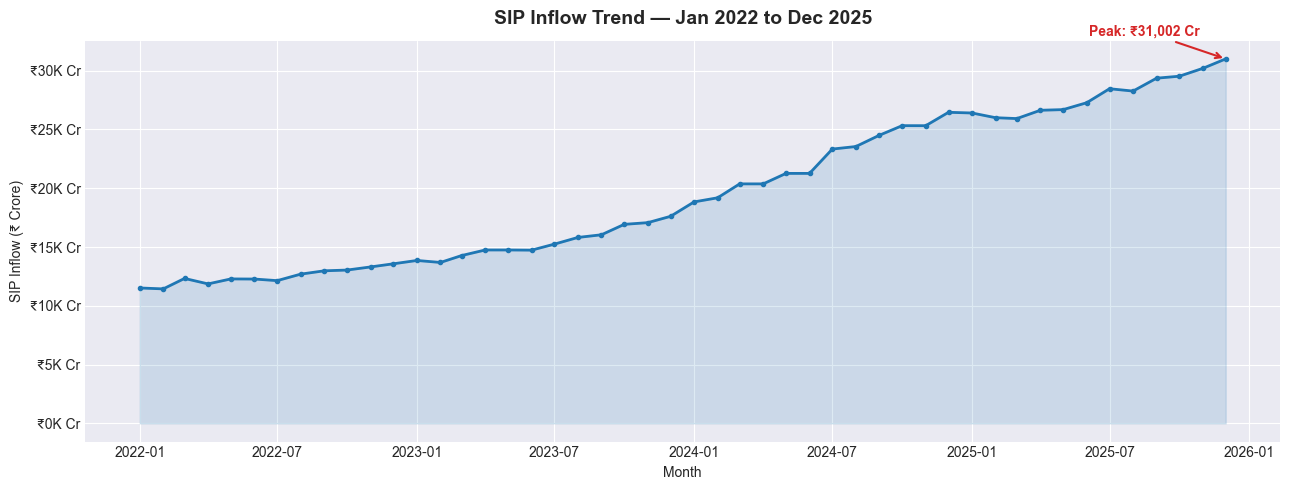

Chart  3/15: SIP Inflow Trend saved to charts/sip_inflow_trend.png


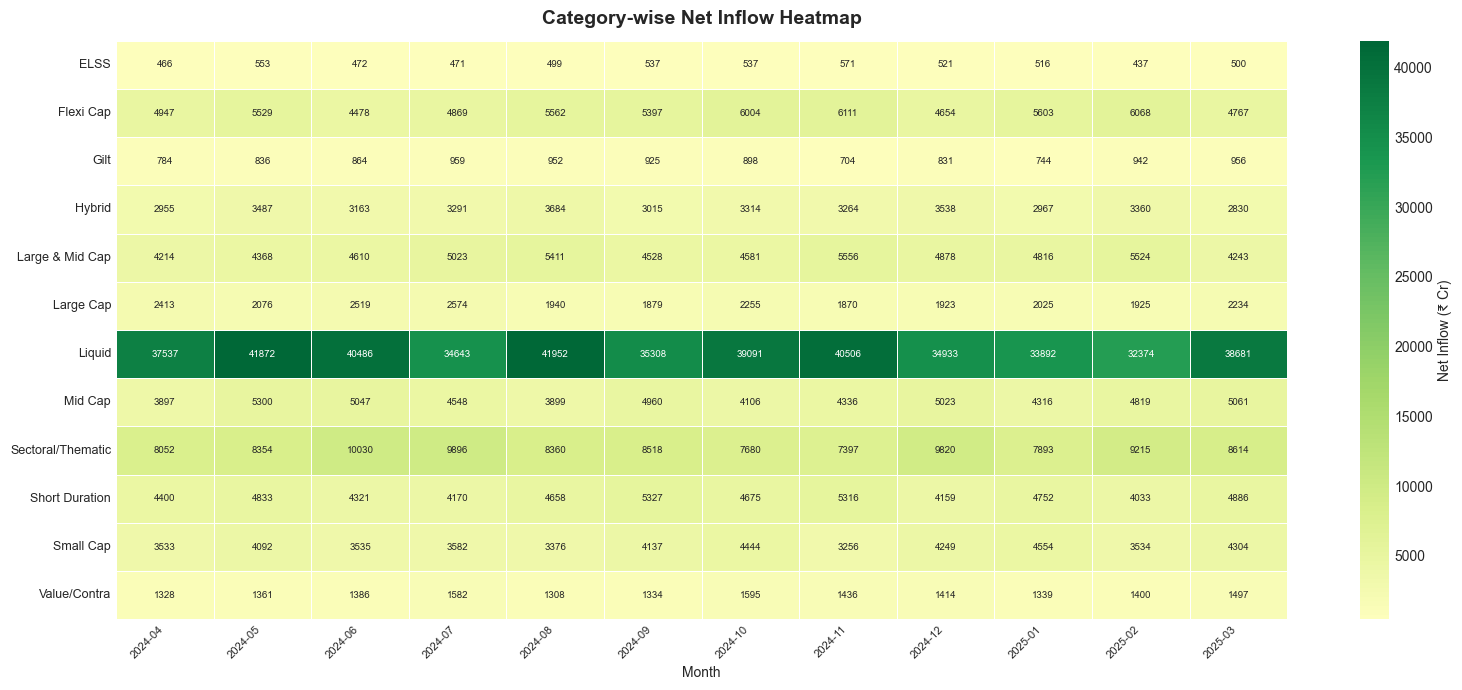

Chart  4/15: Category-wise Inflow Heatmap saved to charts/category_inflow_heatmap.png


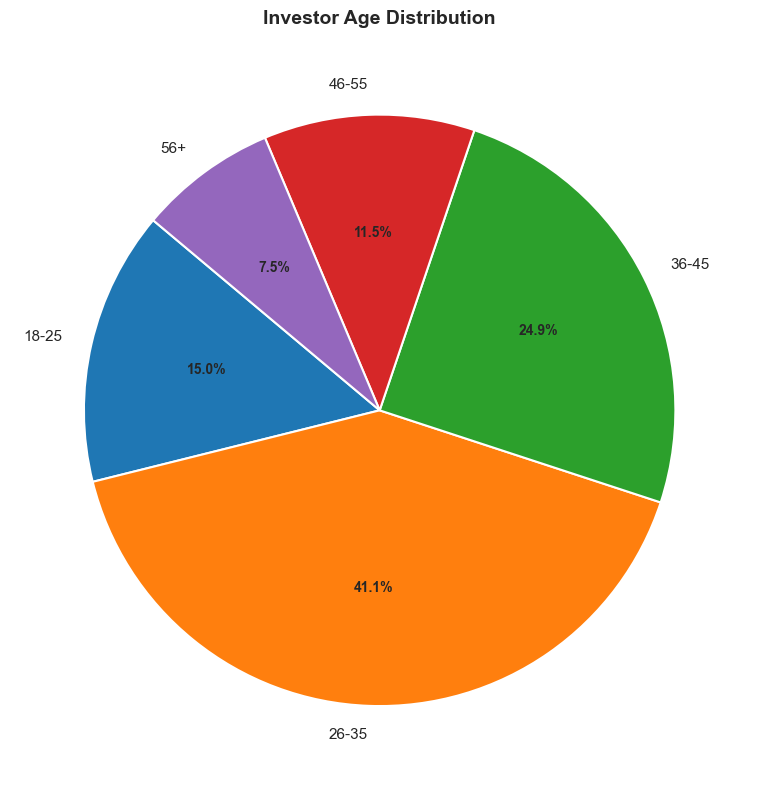

Chart  5/15: Investor Age Distribution saved to charts/investor_age_distribution.png


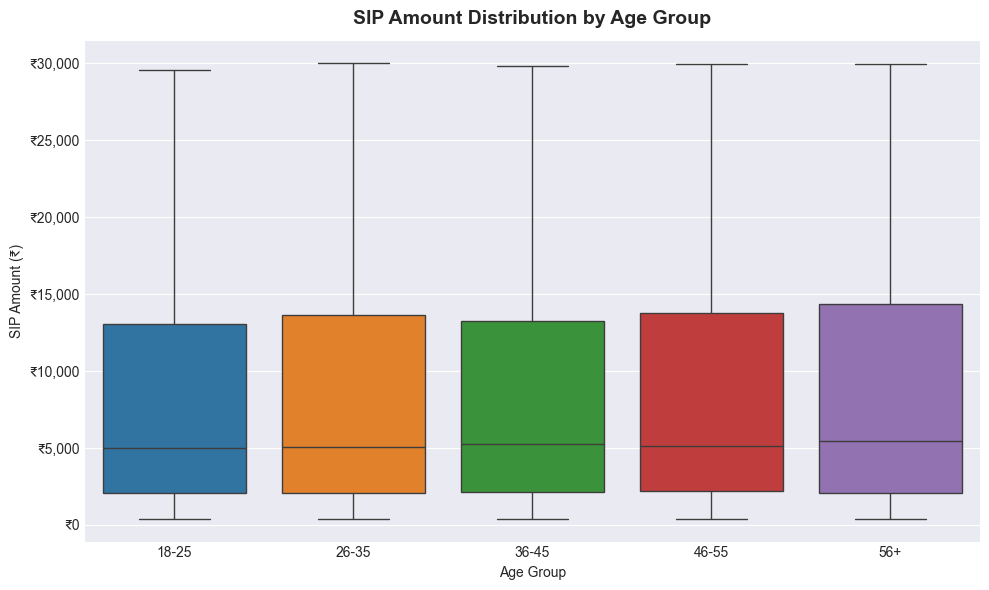

Chart  6/15: SIP Amount by Age Group saved to charts/sip_amount_by_age.png


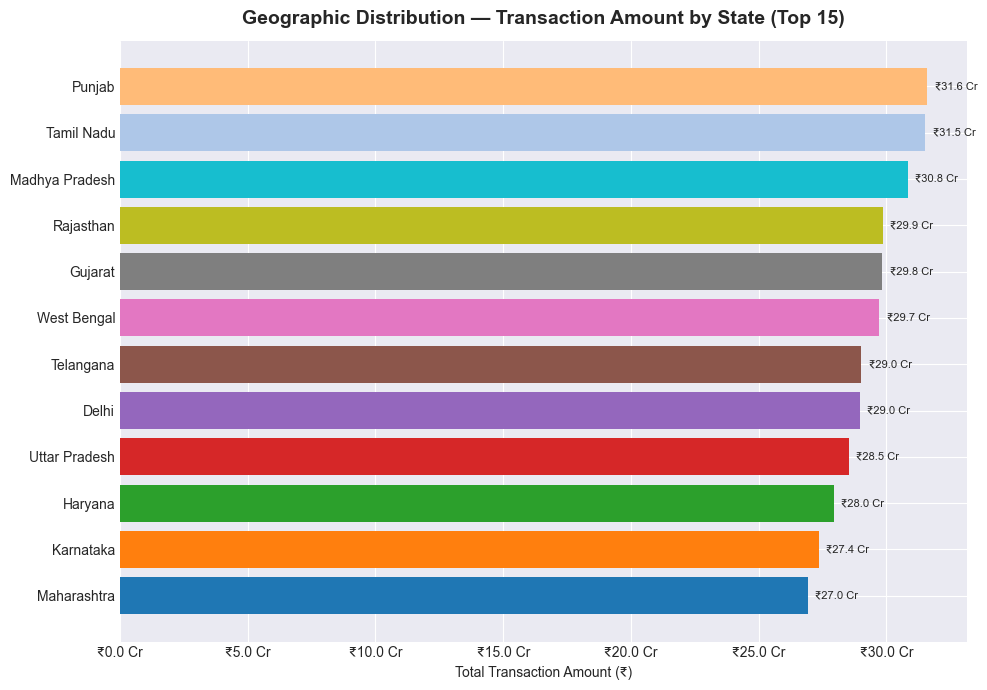

Chart  7/15: Geographic Distribution saved to charts/geographic_distribution.png


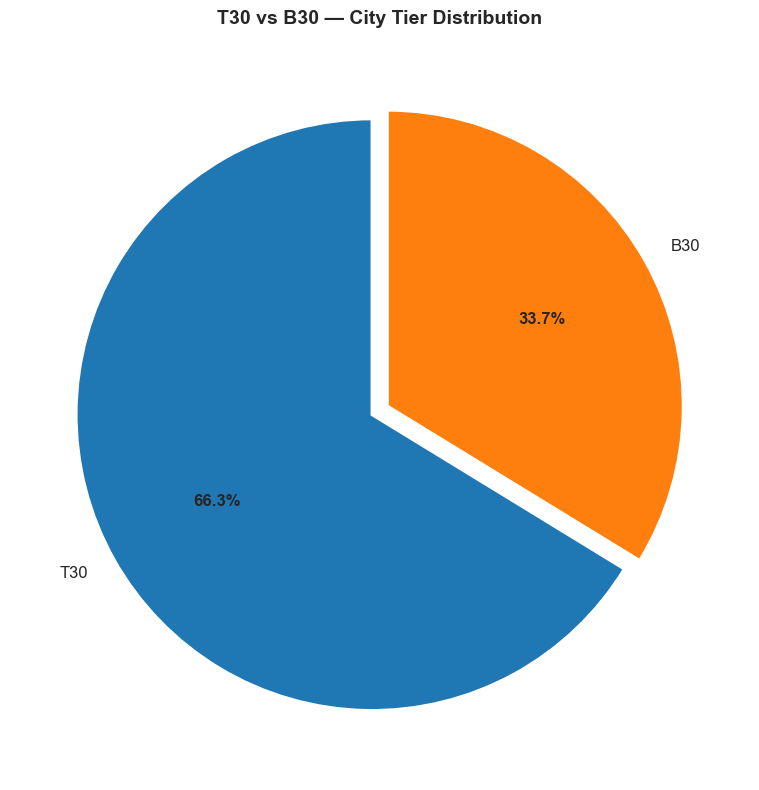

Chart  8/15: T30 vs B30 Distribution saved to charts/t30_vs_b30.png


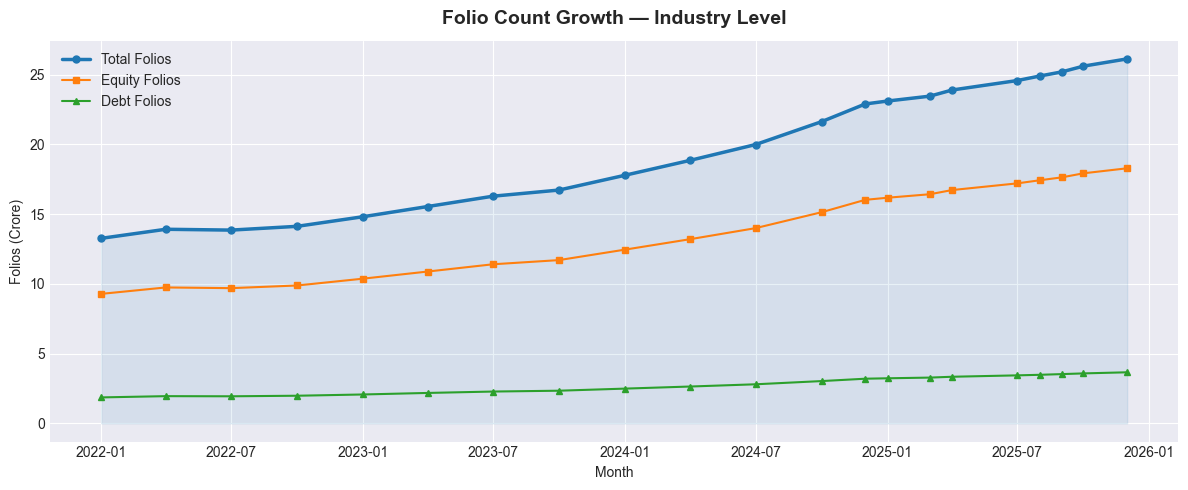

Chart  9/15: Folio Count Growth saved to charts/folio_count_growth.png


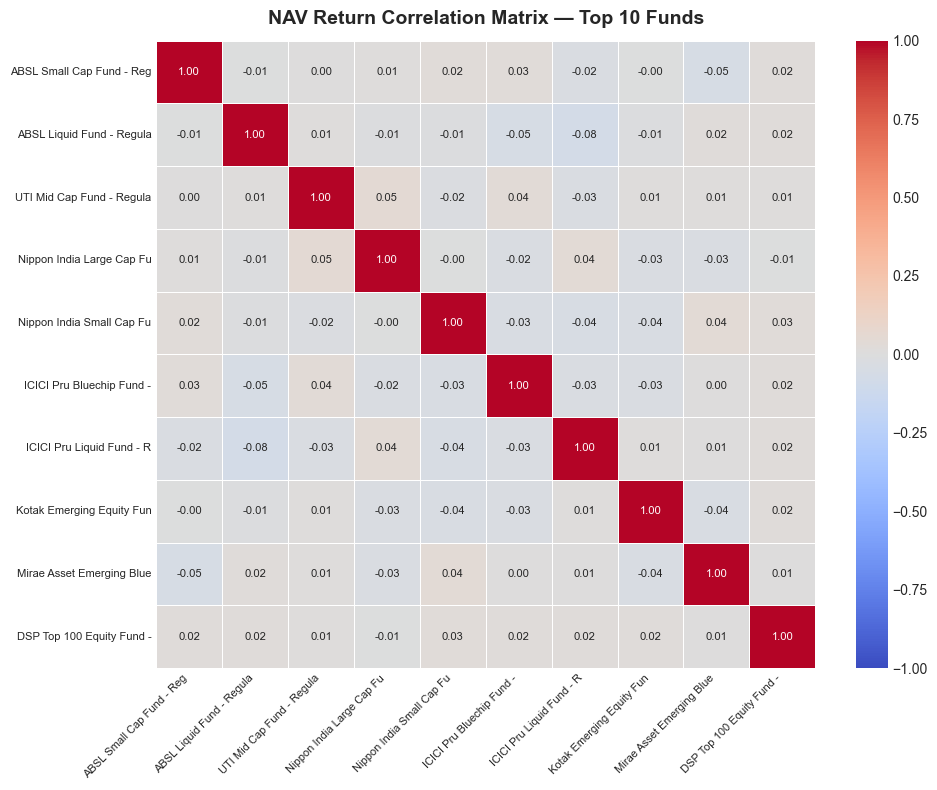

Chart 10/15: NAV Return Correlation Matrix saved to charts/nav_return_correlation.png


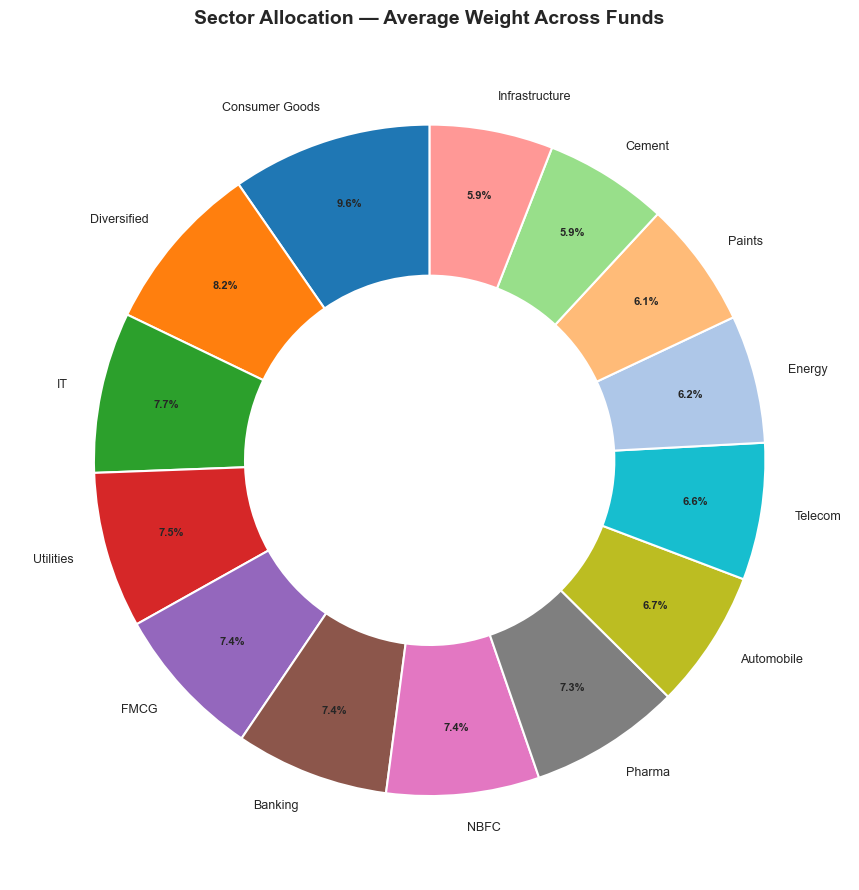

Chart 11/15: Sector Allocation Donut saved to charts/sector_allocation_donut.png


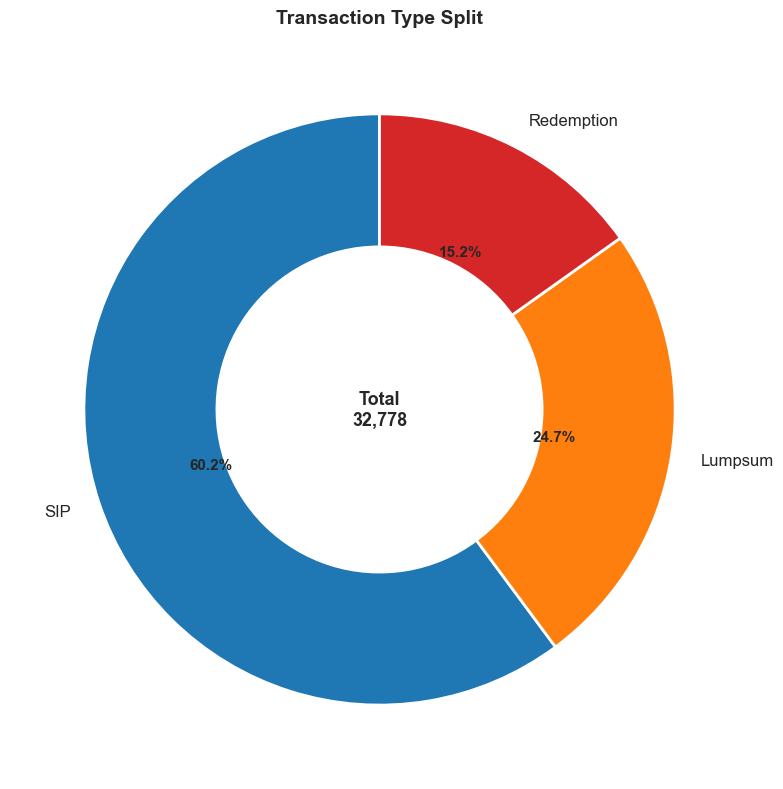

Chart 12/15: Transaction Type Split saved to charts/transaction_type_split.png


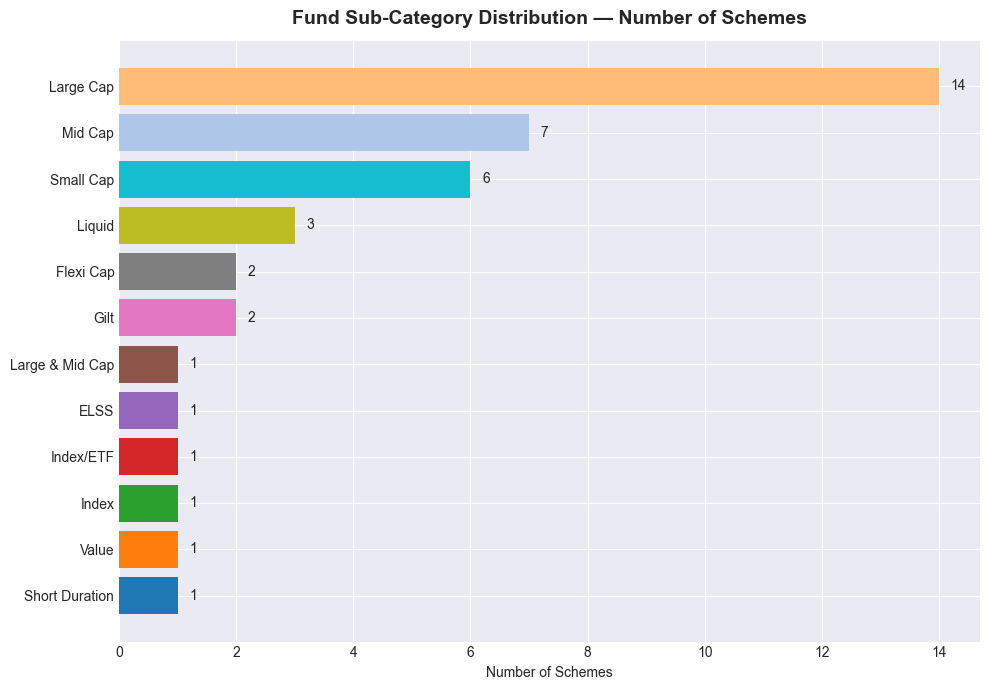

Chart 13/15: Fund Category Distribution saved to charts/fund_category_distribution.png


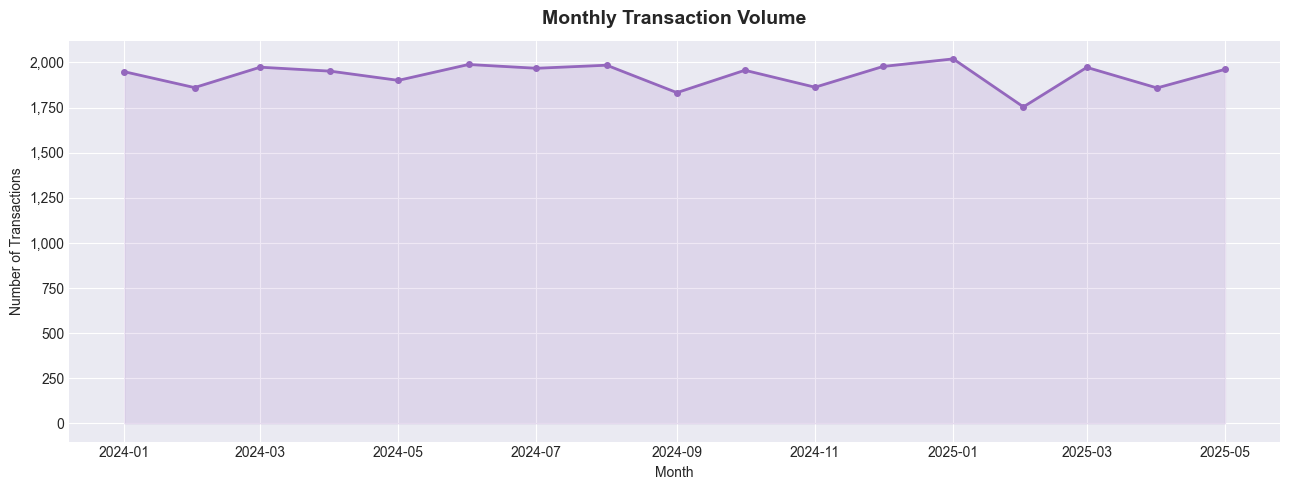

Chart 14/15: Monthly Transaction Volume saved to charts/monthly_transaction_volume.png


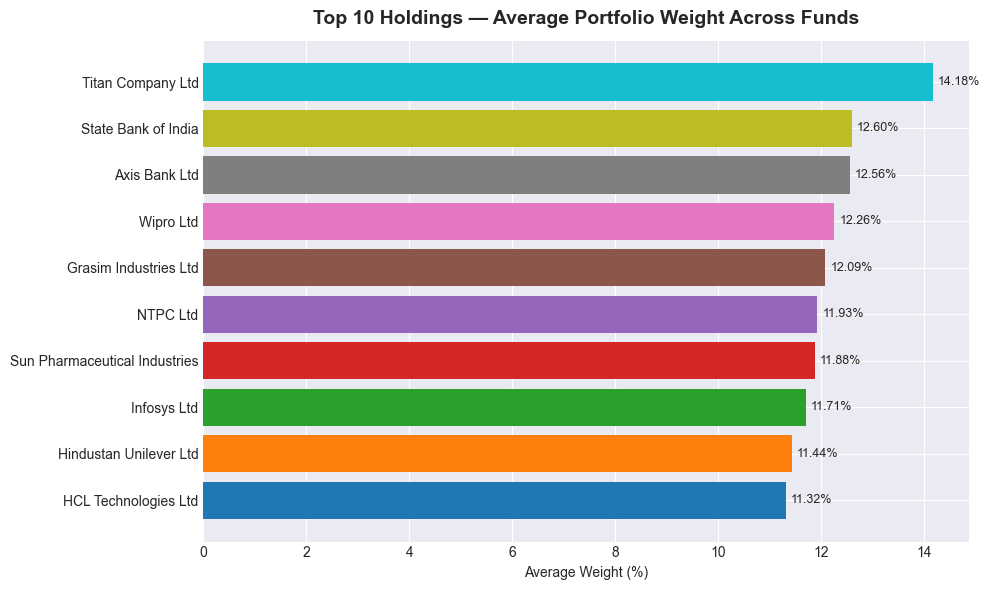

Chart 15/15: Top 10 Holdings saved to charts/top_10_holdings.png

  10 KEY EDA FINDINGS
   1. SIP inflows grew 169% from ₹11,517 Cr (Jan-22) to ₹31,002 Cr (Dec-25)
   2. Industry folios doubled from 13.26 Cr to 26.12 Cr over the period
   3. Age group '26-35' dominates with 41.1% of all transactions
   4. T30 cities contribute 66.3% of transactions; B30 still at 33.7%
   5. Punjab is the largest contributor by transaction value
   6. SIP transactions (19,716) outnumber lumpsum, showing systematic investing trend
   7. Regular plans avg expense ratio (1.35%) is ~0.57% higher than Direct (0.78%)
   8. Best 3yr performer: SBI Small Cap Fund - Regular Plan - Grow with 23.39% CAGR
   9. 'Consumer Goods' is the most weighted sector at 14.18% avg weight
  10. Fund universe spans 12 sub-categories across 2 broad categories with 40 schemes

All 15 charts saved to: C:\Users\prati\.gemini\antigravity\scratch\bluestock_project\charts
EDA analysis complete!
Function print_eda_findings defined succe

In [18]:
def print_eda_findings(data):
    """Print 10 key EDA findings as bullet points."""
    txn = data["transactions"]
    sip = data["sip"]
    folio = data["folio"]
    fm = data["fund_master"]
    perf = data["performance"]
    hold = data["holdings"]

    findings = []

    # 1. SIP growth
    sip_start = sip["sip_inflow_crore"].iloc[0]
    sip_end = sip["sip_inflow_crore"].iloc[-1]
    findings.append(f"SIP inflows grew {((sip_end/sip_start)-1)*100:.0f}% from ₹{sip_start:,.0f} Cr (Jan-22) to ₹{sip_end:,.0f} Cr (Dec-25)")

    # 2. Folio growth
    f_start = folio["total_folios_crore"].iloc[0]
    f_end = folio["total_folios_crore"].iloc[-1]
    findings.append(f"Industry folios doubled from {f_start:.2f} Cr to {f_end:.2f} Cr over the period")

    # 3. Age distribution
    dominant_age = txn["age_group"].value_counts().idxmax()
    dominant_pct = (txn["age_group"].value_counts().max() / len(txn)) * 100
    findings.append(f"Age group '{dominant_age}' dominates with {dominant_pct:.1f}% of all transactions")

    # 4. T30 vs B30
    t30_pct = (txn["city_tier"] == "T30").mean() * 100
    findings.append(f"T30 cities contribute {t30_pct:.1f}% of transactions; B30 still at {100-t30_pct:.1f}%")

    # 5. Top state
    top_state = txn.groupby("state")["amount_inr"].sum().idxmax()
    findings.append(f"{top_state} is the largest contributor by transaction value")

    # 6. SIP vs Lumpsum
    sip_count = (txn["transaction_type"] == "SIP").sum()
    findings.append(f"SIP transactions ({sip_count:,}) outnumber lumpsum, showing systematic investing trend")

    # 7. Expense ratio
    avg_exp_reg = fm[fm["plan"] == "Regular"]["expense_ratio_pct"].mean()
    avg_exp_dir = fm[fm["plan"] == "Direct"]["expense_ratio_pct"].mean()
    findings.append(f"Regular plans avg expense ratio ({avg_exp_reg:.2f}%) is ~{avg_exp_reg-avg_exp_dir:.2f}% higher than Direct ({avg_exp_dir:.2f}%)")

    # 8. Top performer
    best = perf.nlargest(1, "return_3yr_pct").iloc[0]
    findings.append(f"Best 3yr performer: {best['scheme_name'][:40]} with {best['return_3yr_pct']:.2f}% CAGR")

    # 9. Sector concentration
    top_sector = hold.groupby("sector")["weight_pct"].mean().idxmax()
    top_sector_wt = hold.groupby("sector")["weight_pct"].mean().max()
    findings.append(f"'{top_sector}' is the most weighted sector at {top_sector_wt:.2f}% avg weight")

    # 10. Category diversity
    n_cats = fm["sub_category"].nunique()
    findings.append(f"Fund universe spans {n_cats} sub-categories across {fm['category'].nunique()} broad categories with {len(fm)} schemes")

    print("\n" + "="*70)
    print("  10 KEY EDA FINDINGS")
    print("="*70)
    for i, f in enumerate(findings, 1):
        print(f"  {i:2d}. {f}")
    print("="*70 + "\n")


# ──────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────
if __name__ == "__main__":
    print("="*60)
    print("  BLUESTOCK MF CAPSTONE — EDA ANALYSIS")
    print("  Generating 15 charts...")
    print("="*60 + "\n")

    data = load_data()
    print(f"Loaded {len(data)} datasets.\n")

    chart_nav_trend(data)
    chart_aum_growth(data)
    chart_sip_inflow(data)
    chart_category_heatmap(data)
    chart_age_distribution(data)
    chart_sip_amount_by_age(data)
    chart_geographic_distribution(data)
    chart_t30_b30(data)
    chart_folio_growth(data)
    chart_nav_correlation(data)
    chart_sector_donut(data)
    chart_transaction_type(data)
    chart_fund_category(data)
    chart_monthly_volume(data)
    chart_top_holdings(data)

    print_eda_findings(data)
    print("All 15 charts saved to:", CHARTS)
    print("EDA analysis complete!")

print('Function print_eda_findings defined successfully.')
